In [ ]:
 
import h5py
import numpy as np
import pandas as pd
import nibabel as nb
from numpy import genfromtxt
from brainspace.utils.parcellation import reduce_by_labels
from brainspace.gradient import GradientMaps
import seaborn as sns
from scipy.interpolate import griddata
import copy 

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap
import matplotlib as mpl 
   
import sys, os
sys.path.append('/data/p_02542/dekrak/scripts/hippunfold_toolbox')
from hippunfold_toolbox import plotting
import hippunfold_toolbox



In [ ]:
       
subjlist = '...subjectListS1200_qc_pass.txt'
f = open(subjlist); mylist = f.read().split("\n"); f.close() 
subjlist = joinedlist = mylist[:-1]

mysubjects = []
for subj in subjlist:
    mysubjects.append(subj)  

surf_ave = nb.load(os.path.join('...label-hipp_midthickness.surf.gii'))

coords = surf_ave.agg_data()[0]
tris = surf_ave.agg_data()[1] 

In [ ]:
 
# Identifies the sign of the splits with respect to the first split  

def check_flipped_splits(csv_filepath):
    df = pd.read_csv(csv_filepath)
    other_splits = ['split_2', 'split_3', 'split_4', 'split_5']
    
    # split_1 is the reference split 

    signs = {'split_1': 1}
    
    for split in other_splits:
        correlation = df['split_1'].corr(df[split])
        signs[split] = -1 if correlation < 0 else 1
        
    return signs  
 

In [ ]:

updir = os.path.join('..._HippCurv_BehScorings_regOutAgeGender/',
                   '..._HippCurv_BehScorings_regOutAgeGender/framework/',
                   '..._rcca_a1_regOutAgeGender/res/level1/')

aname_curv = os.path.join(updir, 'correlationX_allsplits.csv')

# taking all the 5 splits 


curv_XallSplits = pd.read_csv(aname_curv)

file_path = ".../correlationY_allsplits.csv"

split_signs = check_flipped_splits(file_path) 
 
# Caricamento e allineamento di segno degli split
curv_XallSplits = pd.read_csv(aname_curv)

# Align the splits so that they are all  

for col, sign in split_signs.items():
    if col in curv_XallSplits.columns:
        curv_XallSplits[col] = curv_XallSplits[col] * sign 
 
curvMEAN = np.array(curv_XallSplits.mean(axis=1))
curvSTD = np.array(curv_XallSplits.std(axis=1))


In [ ]:
 

def fillnanvertices(F,V):
    
    '''Fills NaNs by iteratively nanmean nearest neighbours until no NaNs remain. Can be used to fill missing vertices OR missing vertex cdata.'''

    Vnew = copy.deepcopy(V)
    while np.isnan(np.sum(Vnew)):
        # index of vertices containing nan 
        vrows = np.unique(np.where(np.isnan(Vnew))[0])
        # replace with the nanmean of neighbouring vertices
        for n in vrows:
            frows = np.where(F == n)[0]
            neighbours = np.unique(F[frows,:])
            Vnew[n] = np.nanmean(Vnew[neighbours], 0)
    return Vnew  
    


In [ ]:
# interpolate the metrics  

def interpolate_hipp_metrics( MEAN, STD, resources_dir='.../resources/', indensity='2mm', outdensity='0p5mm', method='nearest'):
     
    input_surf = nb.load(f'{resources_dir}/unfold_template_hipp/tpl-avg_space-unfold_den-{indensity}_midthickness.surf.gii')
    vertices_input = input_surf.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
 
    output_surf = nb.load(f'{resources_dir}/unfold_template_hipp/tpl-avg_space-unfold_den-{outdensity}_midthickness.surf.gii')
    vertices_output = output_surf.get_arrays_from_intent('NIFTI_INTENT_POINTSET')[0].data
    faces = output_surf.get_arrays_from_intent('NIFTI_INTENT_TRIANGLE')[0].data
 
    MEAN_interp = griddata(vertices_input[:, :2], values=MEAN, xi=vertices_output[:, :2], method=method)
    MEAN_interp = fillnanvertices(faces, MEAN_interp)
 
    STD_interp = griddata(vertices_input[:, :2], values=STD, xi=vertices_output[:, :2], method=method)
    STD_interp = fillnanvertices(faces, STD_interp)
     
    return MEAN_interp, STD_interp

 

In [ ]:
 
curvMEAN_interp, curvSTD_interp = interpolate_hipp_metrics(curvMEAN, curvSTD, resources_dir=resources_dir)


In [ ]:

curvMEAN_interp.min(), curvMEAN_interp.max()


(-0.231512266133383, 0.1694353467758262)

In [ ]:

def plot_gifti_metric(surf_ave, metric_data, metric_name="...", cmap_name='RdBu_r', elev=90, azim=-90, _vmin=-0.5, _vmax=0.5):
    
    coords = surf_ave.agg_data()[0]
    tris = surf_ave.agg_data()[1]
    
    faces = surf_ave.darrays[1].data 
     
    face_values = (metric_data)[faces].mean(axis=1)
 
    base_cmap = mpl.colormaps[cmap_name]
    vals = base_cmap(np.linspace(0, 1, 256)) 
    my_custom_cmap = ListedColormap(vals)
 
    fig, ax = plotting.plot_gifti(surf_ave, 'fill', cmap=False)

    mappable = ax.collections[0] 
    mappable.set_array(face_values)  
    mappable.set_edgecolor('none') 
    mappable.set_cmap(my_custom_cmap)
  
    norm = Normalize(vmin = _vmin, vmax = _vmax)
    mappable.set_norm(norm)
 
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6)
    cbar.set_label(metric_name)

    ax.view_init(elev=elev, azim=azim) 

    plt.show()
    return fig, ax 



In [ ]:
 
plot_gifti_metric(surf_ave, curvMEAN_interp, metric_name="curv") 
  


# Behavioral loadings 


In [ ]:
 
updirsurfc = os.path.join("/data/p_02542/dekrak/scripts/Matteo_Scripts/left_hippocampus/cca/results/1_HCP-YA_n856_HippCurv_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a1_regOutAgeGender/res/level1/")


aname_surfc = os.path.join(updirsurfc, 'correlationY_allsplits.csv')


Beh_curv_1 = pd.read_csv(aname_surfc)


In [ ]:

Beh_curv_1


,Label,Category,split_1,split_2,split_3,split_4,split_5
0,Subjective sleep quality1,Alertness,-0.029742,-0.084537,-0.088321,0.126150,0.121389
1,Sleep latency,Alertness,0.181855,0.111471,-0.138418,0.278169,0.226968
2,Sleep disturbance,Alertness,-0.016795,0.052288,-0.161803,0.133512,0.114641
3,Use of sleep meds,Alertness,0.084218,0.016538,-0.012823,0.017031,0.046293
4,Daytime dysfunction,Alertness,-0.090622,-0.129571,-0.029372,-0.017348,0.014131
5,Episodic memory,Cognition,-0.574356,-0.485856,0.497862,-0.466026,-0.473307
6,Executive function/Cognitive flexibility,Cognition,-0.211154,-0.267402,0.306300,-0.258006,-0.344922
7,Executive function/Inhibition,Cognition,-0.198138,-0.201065,0.175195,-0.274825,-0.262026
8,Language/Reading decoding,Cognition,-0.446162,-0.645391,0.686107,-0.611358,-0.639717
9,Language/Vocabulary comprehension,Cognition,-0.483918,-0.679645,0.725618,-0.668402,-0.680929


In [ ]:


def get_initials(label):
    """
    Standardized mapping for HCP behavioral variables.
    """
    mapping = {
        "Subjective sleep quality1": "SSQ1",
        "Sleep latency": "SL",
        "Sleep disturbance": "SD",
        "Use of sleep meds": "USM",
        "Daytime dysfunction": "DD",
        "Episodic memory": "EM",
        "Executive function/Cognitive flexibility": "EF/CF",
        "Executive function/Inhibition": "EF/I",
        "Language/Reading decoding": "L/RD",
        "Language/Vocabulary comprehension": "L/VC",
        "Processing speed": "PS",
        "Self-regulation/Impulsivity1": "SR/I1",
        "Self-regulation/Impulsivity2": "SR/I2",
        "Working memory": "WM",
        "Emotion recognition - CR": "ER-C",
        "Emotion recognition - RT-CR Rev": "ER-R",
        "Anger - Irritability/frustration": "A-IF",
        "Hostility/cynicism": "H/C",
        "Physical aggression": "PA",
        "Fear": "F",
        "Somatic symptoms of anxiety": "SSA",
        "Sadness": "S",
        "Life satisfaction": "LS",
        "Meaning/Purpose": "M/P",
        "Friendship": "FR",
        "Loneliness": "L",
        "Hostility": "H",
        "Rejection": "R",
        "Emotional support": "ES",
        "Instrumental support": "IS",
        "Stress": "ST",
        "Self-efficacy": "SE"
    }
    return mapping.get(label, "".join([w[0].upper() for w in label.replace('/',' ').replace('-',' ').split()]))


In [ ]:
# Plotting the behavioral loading of the first split  

def plot_single_split_beh_loadings(res_dir_frwork, level, yfontsize, windowsize, target_split='split_1'):
 
    filename = os.path.join(res_dir_frwork, "correlationY_allsplits.csv")

    T = pd.read_csv(filename)

    T['Category'] = T['Category'].astype(str).str.strip()
    T['Label'] = T['Label'].astype(str).str.strip()
    T['Initials'] = T['Label'].apply(get_initials)
 
    color_map = {'Cognition': '#AEC6CF', 'Alertness': '#FFF9B1', 'Emotion': '#FFB347'}
    
    orig_categ = T['Category'].unique()
    for cat in orig_categ:
        if cat not in color_map:
            color_map[cat] = '#D3D3D3'

    # Sign-Flipping anchored to Cognition
    if 'Cognition' in T['Category'].values: 
        mean_split = T[T['Category'] == 'Cognition'][target_split].mean()
        if mean_split < 0:
            T[target_split] = -T[target_split] 

    T = T.sort_values(by=target_split, ascending=False).reset_index(drop=True)

    plt.figure(figsize=windowsize)

    for category in orig_categ:
        category_data = T[T['Category'] == category]
        plt.bar(category_data.index, category_data[target_split], 
                color=color_map[category], label=category, 
                width=0.8, edgecolor='black', linewidth=0.6)

    plt.ylabel("Correlation", fontsize=19)
    plt.xlabel("Behavioural Variables", fontsize=19)
    plt.xticks(T.index, T['Initials'], fontsize=yfontsize, rotation=45, ha="right") 
     
    
    plt.axhline(0, color='black', linewidth=1.2)
    plt.grid(True, axis='y', linestyle='--', alpha=0.4) 
  
    plt.tight_layout()
    plt.show()


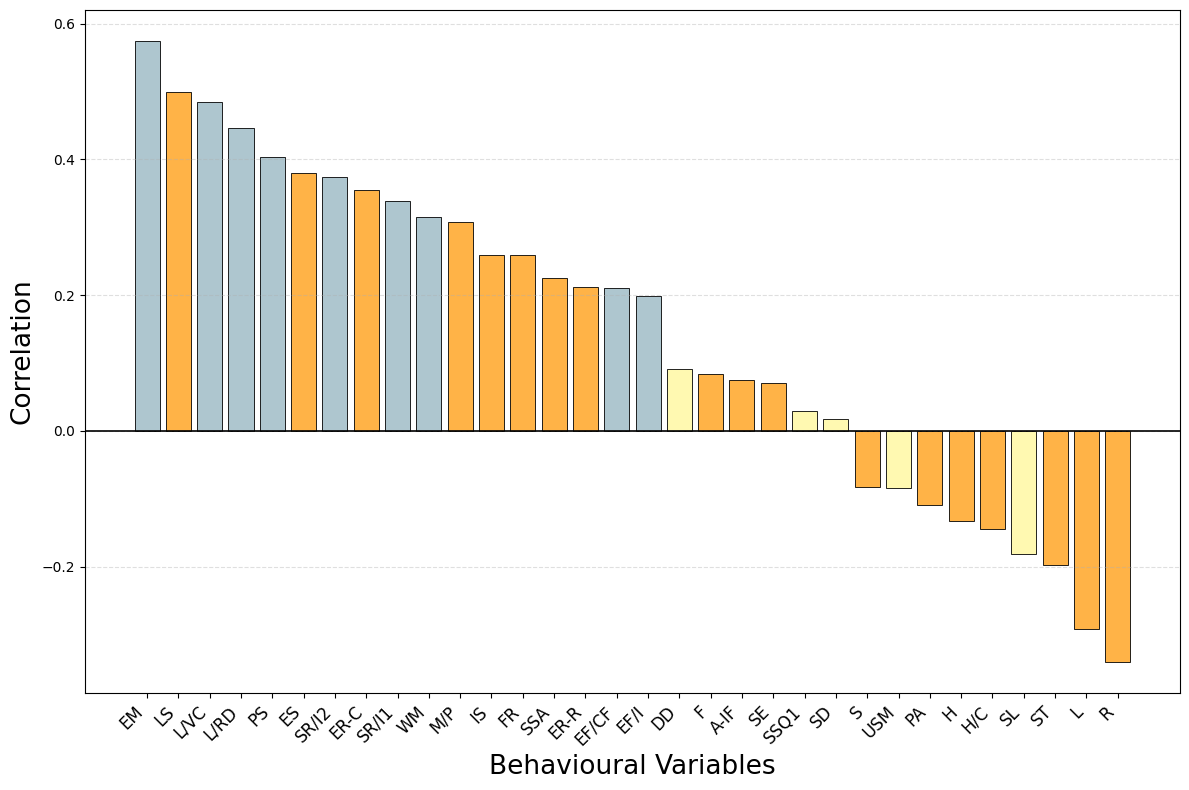

In [ ]:

updirsurfg = "..._HippCurv_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a1_regOutAgeGender/res/level1/"
plot_single_split_beh_loadings(updirsurfg, 1, 12, (12, 8), target_split='split_1')


In [ ]:
 
def plot_avg_beh_loadings(res_dir_frwork, level, windowsize, name, sig_splits, nonsig_splits):
    
    filename = os.path.join(res_dir_frwork, "correlationY_allsplits.csv") 

    T = pd.read_csv(filename)
 
    T['Category'] = T['Category'].astype(str).str.strip()
    T['Label'] = T['Label'].astype(str).str.strip()
    T['Initials'] = T['Label'].apply(get_initials)
 

    color_map = {'Cognition': '#808080', 'Alertness': '#FFF9B1', 'Emotion': '#FFB347'}
    orig_categ = T['Category'].unique()
    for cat in orig_categ:
        if cat not in color_map:
            color_map[cat] = '#D3D3D3'

    splits = ['split_1', 'split_2', 'split_3', 'split_4', 'split_5']

 
    if name.lower() == "curvature":
        T['split_1'] = T['split_1'] * -1
 
    for split in splits[1:]: 
        if T['split_1'].corr(T[split]) < 0:
            T[split] = -T[split] 
 
    T['avg'] = T[splits].mean(axis=1)
    T['stdv'] = T[splits].std(axis=1)
 
    T = T.sort_values(by='avg', ascending=False).reset_index(drop=True)

    # Plot setup
    plt.figure(figsize=windowsize)

    for category in orig_categ:
        category_data = T[T['Category'] == category]
        plt.bar(category_data.index, category_data['avg'], color=color_map[category], label=category, width=0.8, edgecolor='black', linewidth=0.6)

    # Scatter points for significance
    category_plotted = set() 
    for i, row in T.iterrows():
        y_values = row[splits] 
        
        # Determine dot color based on significance
        dot_colors = ['black' if s in sig_splits else 'lightgray' if s in nonsig_splits else 'blue' for s in y_values.index]
        current_cat = row['Category']

        for y, color in zip(y_values, dot_colors):
            plt.scatter(i, y, color=color, edgecolor='black', alpha=0.7)
            if current_cat not in category_plotted:
                category_plotted.add(current_cat)

    plt.ylabel("Correlation", fontsize=19)
    plt.xlabel("Behavioural Variables", fontsize=19)
     
    plt.xticks(T.index, T['Initials'], fontsize=19, rotation=90, ha="center") 
    plt.title(f"Average Behavioral Loading of {name.capitalize()}", fontsize=22)
    
    plt.axhline(0, color='black', linewidth=1.2)
    plt.grid(True, axis='y', linestyle='--', alpha=0.4) 
 
    handles, labels = plt.gca().get_legend_handles_labels() 
    by_label = dict(zip(labels, handles)) 
  
    sig_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='black', markersize=8, label='Significant') 
    nonsig_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markeredgecolor='black', markersize=8, label='Not significant') 
     
    cat_handles = [h for k, h in by_label.items() if k in orig_categ]
    cat_labels = [k for k in by_label.keys() if k in orig_categ]
    
    final_handles = cat_handles + [sig_marker, nonsig_marker] 
    final_labels = cat_labels + ['Significant', 'Not significant'] 
 
    plt.legend(final_handles, final_labels, title="Categories", loc='upper right', title_fontsize=18, fontsize=12) 
    plt.tight_layout() 
 
 
# Dictionary linking markers to directories to their specific significance splits
markers_config = {
    "gyrification": {
        "dir": "...HippGyri_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a2_regOutAgeGender/res/level1/",
        "sig": ['split_1', 'split_4', 'split_5'],
        "nonsig": ['split_2', 'split_3']
    },
    "curvature": {
        "dir": "...HippCurv_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a1_regOutAgeGender/res/level1/",
        "sig": ['split_1'],
        "nonsig": ['split_2', 'split_3', 'split_4', 'split_5']
    },
    "thickness": {
        "dir": "...HippThic_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a5_regOutAgeGender/res/level1/",
        "sig": [],
        "nonsig": ['split_1', 'split_2', 'split_3', 'split_4', 'split_5']
    },
    "myelin": {
        "dir": "...HippMyel_BehScorings_regOutAgeGender/framework/rcca_holdout5-0.20_subsamp5-0.20_rcca_a4_regOutAgeGender/res/level1/",
        "sig": [],
        "nonsig": ['split_1', 'split_2', 'split_3', 'split_4', 'split_5']
    }
}


# Process each marker with its specific parameters

for marker_name, config in markers_config.items():
    plot_avg_beh_loadings(
        res_dir_frwork=config["dir"], 
        level=1, 
        windowsize=(12, 8), 
        name=marker_name, 
        sig_splits=config["sig"], 
        nonsig_splits=config["nonsig"], 
    )
